In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [8]:
#loading the data
df = pd.read_csv('Crime_Data_2010_2017.csv',low_memory=False)
#shape of the data
df.shape
#info about the data
df.info()
#size of the data
df.size
#printing the first 5 rows of the data
df.head()



<class 'pandas.DataFrame'>
RangeIndex: 1584316 entries, 0 to 1584315
Data columns (total 26 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   DR Number               1584316 non-null  int64  
 1   Date Reported           1584316 non-null  str    
 2   Date Occurred           1584316 non-null  str    
 3   Time Occurred           1584316 non-null  int64  
 4   Area ID                 1584316 non-null  int64  
 5   Area Name               1584316 non-null  str    
 6   Reporting District      1584316 non-null  int64  
 7   Crime Code              1584316 non-null  int64  
 8   Crime Code Description  1583904 non-null  str    
 9   MO Codes                1412557 non-null  str    
 10  Victim Age              1455657 non-null  float64
 11  Victim Sex              1439117 non-null  str    
 12  Victim Descent          1439084 non-null  str    
 13  Premise Code            1584240 non-null  float64
 14  Premise Descr

,DR Number,Date Reported,Date Occurred,Time Occurred,Area ID,Area Name,Reporting District,Crime Code,Crime Code Description,MO Codes,...,Weapon Description,Status Code,Status Description,Crime Code 1,Crime Code 2,Crime Code 3,Crime Code 4,Address,Cross Street,Location
0,1208575,03/14/2013,03/11/2013,1800,12,77th Street,1241,626,INTIMATE PARTNER - SIMPLE ASSAULT,0416 0446 1243 2000,...,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,626.0,NaN,NaN,NaN,6300 BRYNHURST AV,NaN,"(33.9829, -118.3338)"
1,102005556,01/25/2010,01/22/2010,2300,20,Olympic,2071,510,VEHICLE - STOLEN,NaN,...,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,VAN NESS,15TH,"(34.0454, -118.3157)"
2,418,03/19/2013,03/18/2013,2030,18,Southeast,1823,510,VEHICLE - STOLEN,NaN,...,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,200 E 104TH ST,NaN,"(33.942, -118.2717)"
3,101822289,11/11/2010,11/10/2010,1800,18,Southeast,1803,510,VEHICLE - STOLEN,NaN,...,NaN,IC,Invest Cont,510.0,NaN,NaN,NaN,88TH,WALL,"(33.9572, -118.2717)"
4,42104479,01/11/2014,01/04/2014,2300,21,Topanga,2133,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),0329,...,NaN,IC,Invest Cont,745.0,NaN,NaN,NaN,7200 CIRRUS WY,NaN,"(34.2009, -118.6369)"


Null check

In [5]:
df.isnull().sum().sort_values(ascending=False)


Crime Code 4              1584247
Crime Code 3              1582133
Crime Code 2              1484319
Cross Street              1321583
Weapon Description        1059560
Weapon Used Code          1059559
MO Codes                   171759
Victim Descent             145232
Victim Sex                 145199
Victim Age                 128659
Premise Description          2751
Crime Code Description        412
Premise Code                   76
Location                        9
Crime Code 1                    7
Status Code                     2
DR Number                       0
Date Reported                   0
Reporting District              0
Crime Code                      0
Area ID                         0
Area Name                       0
Time Occurred                   0
Date Occurred                   0
Status Description              0
Address                         0
dtype: int64

Crime codes column delete cause already have unique column Crime code

In [6]:
# dropping unnecessary columns
df.drop(columns=['Crime Code 1', 'Crime Code 2', 'Crime Code 3', 'Crime Code 4'], inplace=True)




In [7]:
#check table after dropping columns
df.head()
#shape of the data after dropping columns
df.shape

(1584316, 22)

Date format check is that str or date time format(cause without dat-time format can't analize crime)

In [8]:
# converting date columns to datetime format
df['Date Reported'] = pd.to_datetime(df['Date Reported'], format='%m/%d/%Y', errors='coerce')
df['Date Occurred'] = pd.to_datetime(df['Date Occurred'], format='%m/%d/%Y', errors='coerce')
#checking the data types of the columns after conversion
df[['Date Reported', 'Date Occurred']].dtypes


Date Reported    datetime64[us]
Date Occurred    datetime64[us]
dtype: object

Time Occured wrong checks and fix 

In [9]:
# extracting hour from Time Occurred
df['Hour Occurred'] = df['Time Occurred'].astype(str).str.zfill(4).str[:2].astype(int) #converting Time Occurred to string, padding with zeros, extracting the hour part, and converting back to integer


Check the times hour occurred column now

In [10]:
df['Hour Occurred'].unique() # checking the unique values in the Hour Occurred column to identify any incorrect time values


array([18, 23, 20, 14, 22, 16,  8, 21, 13, 12,  5, 15, 17,  1, 11, 19,  3,
       10,  0,  4,  2,  9,  7,  6])

Victim Age clean cause here huge null

In [11]:
# cleaning Victim Age column
df['Victim Age'] = pd.to_numeric(df['Victim Age'], errors='coerce') # converting Victim Age to numeric, coercing errors to NaN for non-numeric values
df['Victim Age'] = df['Victim Age'].where(df['Victim Age'].between(1, 100), np.nan) # replacing values outside the range of 1 to 100 with NaN
df['Victim Age'] = df['Victim Age'].fillna(df['Victim Age'].median()) # filling NaN values with the median age


In [12]:
df['Victim Age'].isnull().sum()


np.int64(0)

Victim sex cleaning

In [13]:
df['Victim Sex'].value_counts(dropna=False) # checking the unique values in the Victim Sex column to identify any incorrect values


Victim Sex
M      739581
F      675402
NaN    145199
X       24080
H          53
-           1
Name: count, dtype: int64

clean victim sex column

In [14]:
# cleaning Victim Sex column
df['Victim Sex'] = df['Victim Sex'].where(df['Victim Sex'].isin(['M', 'F']), 'Unknown')
df['Victim Sex'].value_counts(dropna=False) # checking the unique values in the Victim Sex column to identify any incorrect values

Victim Sex
M          739581
F          675402
Unknown    169333
Name: count, dtype: int64

Victim Descent check

In [15]:
df['Victim Descent'].value_counts(dropna=False) # checking the unique values in the Victim Descent column to identify any incorrect values


Victim Descent
H      549515
W      391855
B      255056
O      152776
NaN    145232
X       41535
A       37143
K        7136
F        1885
I         663
C         618
P         276
J         237
U         137
V          86
G          61
Z          55
S          24
D          15
L          10
-           1
Name: count, dtype: int64

Make dictionary map for descent

In [16]:
# cleaning Victim Descent column
descent_map = {
    'A': 'Asian', 'B': 'Black', 'C': 'Chinese', 'D': 'Cambodian',
    'F': 'Filipino', 'G': 'Guamanian', 'H': 'Hispanic', 'I': 'American Indian',
    'J': 'Japanese', 'K': 'Korean', 'L': 'Laotian', 'O': 'Other',
    'P': 'Pacific Islander', 'S': 'Samoan', 'U': 'Hawaiian',
    'V': 'Vietnamese', 'W': 'White', 'X': 'Unknown', 'Z': 'Asian Indian'
}
df['Victim Descent'] = df['Victim Descent'].map(descent_map).fillna('Unknown')
df['Victim Descent'].value_counts(dropna=False) # checking the unique values in the Victim Descent column to identify any incorrect values

Victim Descent
Hispanic            549515
White               391855
Black               255056
Unknown             186768
Other               152776
Asian                37143
Korean                7136
Filipino              1885
American Indian        663
Chinese                618
Pacific Islander       276
Japanese               237
Hawaiian               137
Vietnamese              86
Guamanian               61
Asian Indian            55
Samoan                  24
Cambodian               15
Laotian                 10
Name: count, dtype: int64

Location column

In [17]:
print(df.columns)

Index(['DR Number', 'Date Reported', 'Date Occurred', 'Time Occurred',
       'Area ID', 'Area Name', 'Reporting District', 'Crime Code',
       'Crime Code Description', 'MO Codes', 'Victim Age', 'Victim Sex',
       'Victim Descent', 'Premise Code', 'Premise Description',
       'Weapon Used Code', 'Weapon Description', 'Status Code',
       'Status Description', 'Address', 'Cross Street', 'Location ',
       'Hour Occurred'],
      dtype='str')


clean first all column

In [18]:
df.columns = df.columns.str.strip()

In [19]:
df['Location'].head(10)


0    (33.9829, -118.3338)
1    (34.0454, -118.3157)
2     (33.942, -118.2717)
3    (33.9572, -118.2717)
4    (34.2009, -118.6369)
5    (34.0591, -118.2412)
6    (34.1211, -118.2048)
7     (34.241, -118.3987)
8    (34.3147, -118.4589)
9    (34.2012, -118.4662)
Name: Location, dtype: str

Differentiate latitude and longitude

In [20]:
# extracting Latitude and Longitude from Location column
df['Latitude']  = df['Location'].str.extract(r'\(([^,]+),').astype(float) # extracting the latitude part from the Location column using regex and converting to float
df['Longitude'] = df['Location'].str.extract(r',\s*([^)]+)\)').astype(float) # extracting the longitude part from the Location column using regex and converting to float

# dropping original Location column
df.drop(columns=['Location'], inplace=True)


In [21]:
df['Latitude'].head(10)

0    33.9829
1    34.0454
2    33.9420
3    33.9572
4    34.2009
5    34.0591
6    34.1211
7    34.2410
8    34.3147
9    34.2012
Name: Latitude, dtype: float64

In [22]:
df.head()

,DR Number,Date Reported,Date Occurred,Time Occurred,Area ID,Area Name,Reporting District,Crime Code,Crime Code Description,MO Codes,...,Premise Description,Weapon Used Code,Weapon Description,Status Code,Status Description,Address,Cross Street,Hour Occurred,Latitude,Longitude
0,1208575,2013-03-14,2013-03-11,1800,12,77th Street,1241,626,INTIMATE PARTNER - SIMPLE ASSAULT,0416 0446 1243 2000,...,"MULTI-UNIT DWELLING (APARTMENT, DUPLEX, ETC)",400.0,"STRONG-ARM (HANDS, FIST, FEET OR BODILY FORCE)",AO,Adult Other,6300 BRYNHURST AV,NaN,18,33.9829,-118.3338
1,102005556,2010-01-25,2010-01-22,2300,20,Olympic,2071,510,VEHICLE - STOLEN,NaN,...,STREET,NaN,NaN,IC,Invest Cont,VAN NESS,15TH,23,34.0454,-118.3157
2,418,2013-03-19,2013-03-18,2030,18,Southeast,1823,510,VEHICLE - STOLEN,NaN,...,STREET,NaN,NaN,IC,Invest Cont,200 E 104TH ST,NaN,20,33.9420,-118.2717
3,101822289,2010-11-11,2010-11-10,1800,18,Southeast,1803,510,VEHICLE - STOLEN,NaN,...,STREET,NaN,NaN,IC,Invest Cont,88TH,WALL,18,33.9572,-118.2717
4,42104479,2014-01-11,2014-01-04,2300,21,Topanga,2133,745,VANDALISM - MISDEAMEANOR ($399 OR UNDER),0329,...,SINGLE FAMILY DWELLING,NaN,NaN,IC,Invest Cont,7200 CIRRUS WY,NaN,23,34.2009,-118.6369


Weapon column clean

In [23]:
# filling null weapon columns and creating Armed binary feature
df['Weapon Used Code'] = df['Weapon Used Code'].fillna(0) # filling null values in Weapon Used Code with 0, indicating no weapon used
df['Weapon Description'] = df['Weapon Description'].fillna('No Weapon') # filling null values in Weapon Description with 'No Weapon' for better readability
df['Armed'] = (df['Weapon Used Code'] != 0).astype(int) # creating Armed binary feature where 1 indicates a weapon was used and 0 indicates no weapon was used


Check armed 1 0

In [24]:
df['Armed'].value_counts() # checking the unique values in the Armed column to identify any incorrect values

Armed
0    1059559
1     524757
Name: count, dtype: int64

In [25]:
df.shape

(1584316, 25)

Cross street column

In [26]:
# dropping Cross Street column due to excessive nulls
df.drop(columns=['Cross Street'], inplace=True) # dropping Cross Street column due to excessive nulls
df.shape


(1584316, 24)

Mo Codes column

In [27]:
# filling null MO Codes with empty string
df['MO Codes'] = df['MO Codes'].fillna('') # filling null values in MO Codes with empty string for better readability


In [28]:
df['MO Codes'].isnull().sum() # checking for any remaining null values in MO Codes column after filling with empty string


np.int64(0)

DR number column removing duplicate cases based on unique case ID

In [29]:
# removing duplicate cases based on unique case ID
print('Duplicates:', df['DR Number'].duplicated().sum())
df.drop_duplicates(subset='DR Number', keep='first', inplace=True)
print('Final shape:', df.shape)


Duplicates: 0
Final shape: (1584316, 24)


final null check after all cleaning


In [30]:
# final null check after all cleaning
df.isnull().sum().sort_values(ascending=False)


Premise Description       2751
Crime Code Description     412
Premise Code                76
Longitude                    9
Latitude                     9
Status Code                  2
DR Number                    0
Date Reported                0
Crime Code                   0
Reporting District           0
Area Name                    0
Area ID                      0
Time Occurred                0
Date Occurred                0
Victim Sex                   0
MO Codes                     0
Weapon Used Code             0
Victim Descent               0
Victim Age                   0
Weapon Description           0
Address                      0
Status Description           0
Hour Occurred                0
Armed                        0
dtype: int64

Fill remaining nulls

In [31]:
# filling remaining nulls
df['Premise Description'] = df['Premise Description'].fillna(df['Premise Description'].mode()[0]) # filling null values in Premise Description with the most common value for better readability
df['Crime Code Description'] = df['Crime Code Description'].fillna(df['Crime Code Description'].mode()[0]) # filling null values in Crime Code Description with the most common value for better readability
df['Premise Code'] = df['Premise Code'].fillna(df['Premise Code'].mode()[0]) # filling null values in Premise Code with the most common value for better readability
df['Status Code'] = df['Status Code'].fillna(df['Status Code'].mode()[0]) # filling null values in Status Code with the most common value for better readability

# dropping rows where location is missing
df = df.dropna(subset=['Latitude', 'Longitude']) # dropping rows where location is missing

print('Final shape:', df.shape) # printing final shape of the cleaned data
df.isnull().sum().sum() # checking for any remaining null values in the cleaned data


Final shape: (1584307, 24)


np.int64(0)

taking 20% sample for faster processing


In [32]:
# taking 20% sample for faster processing
df = df.sample(frac=0.2, random_state=42)
print('Sampled shape:', df.shape)


Sampled shape: (316861, 24)


Top 20 crime types chart:

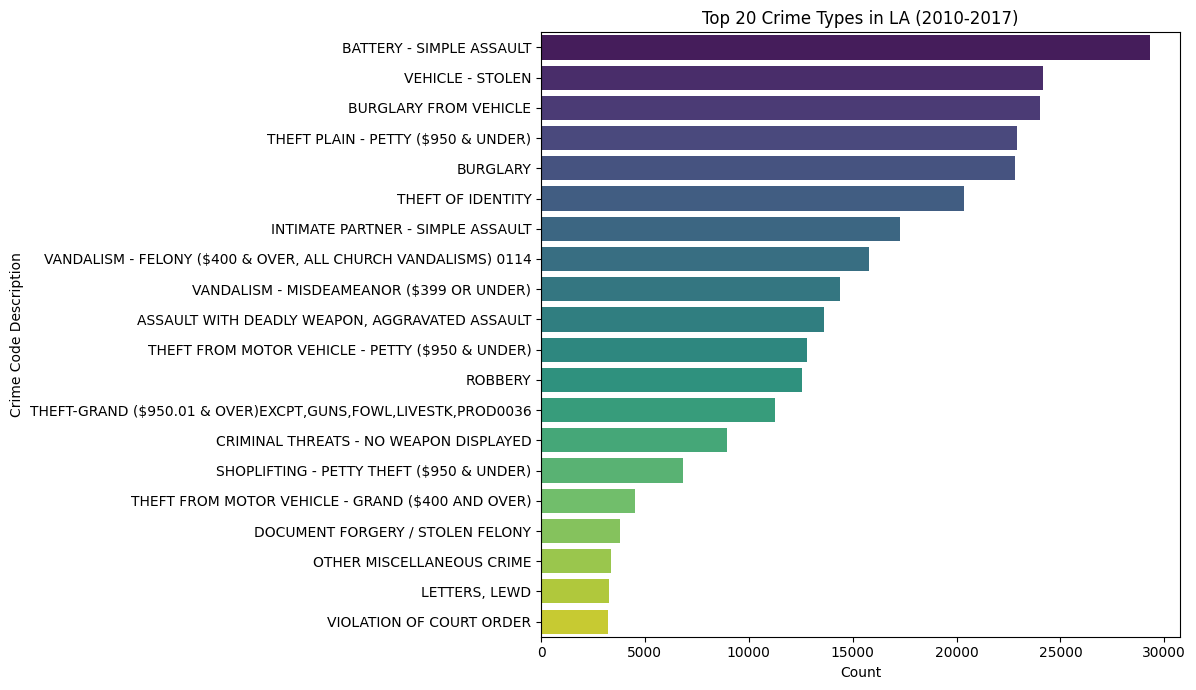

In [33]:
top_crimes = df['Crime Code Description'].value_counts().head(20) # getting the top 20 most common crime types

plt.figure(figsize=(12, 7)) # setting figure size
sns.barplot(x=top_crimes.values, y=top_crimes.index, hue=top_crimes.index, palette='viridis', legend=False)# creating bar plot with hue for better visual distinction between crime types
plt.title('Top 20 Crime Types in LA (2010-2017)') # setting title
plt.xlabel('Count') # setting x-axis label
plt.tight_layout() # adjusting layout
plt.show() # displaying plot


Temporal Analysis 

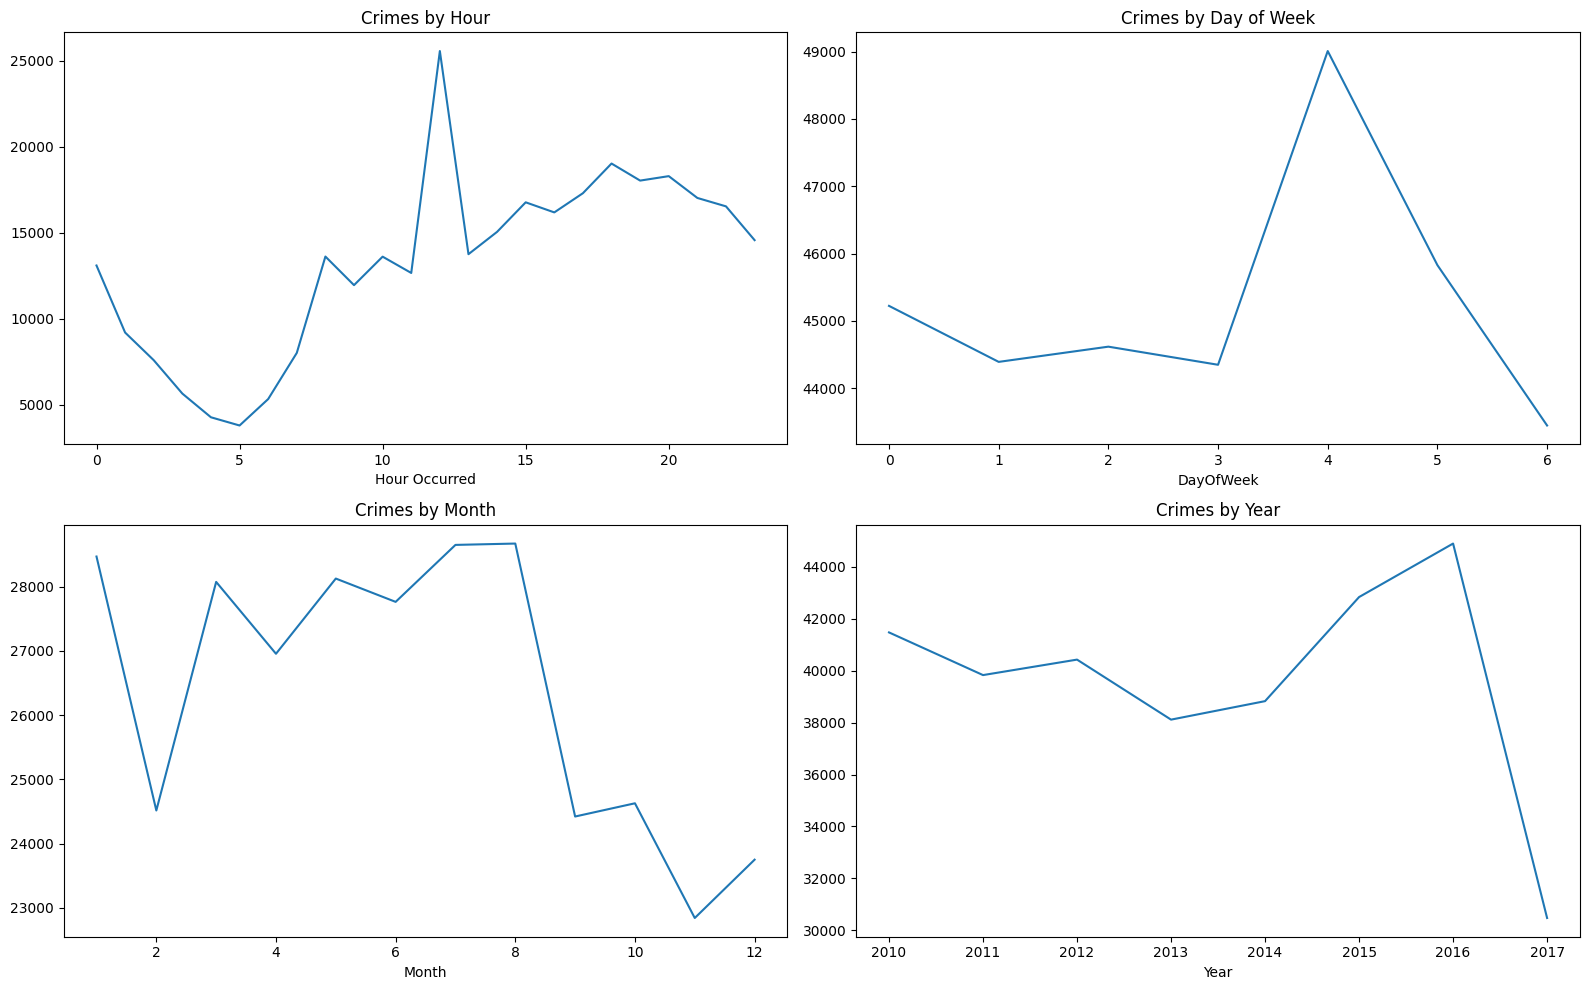

In [34]:
df['Year']      = df['Date Occurred'].dt.year
df['Month']     = df['Date Occurred'].dt.month
df['DayOfWeek'] = df['Date Occurred'].dt.dayofweek

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

df['Hour Occurred'].value_counts().sort_index().plot(ax=axes[0,0], title='Crimes by Hour')
df['DayOfWeek'].value_counts().sort_index().plot(ax=axes[0,1], title='Crimes by Day of Week')
df['Month'].value_counts().sort_index().plot(ax=axes[1,0], title='Crimes by Month')
df['Year'].value_counts().sort_index().plot(ax=axes[1,1], title='Crimes by Year')

plt.tight_layout()
plt.show()


Victim Demographics chart:

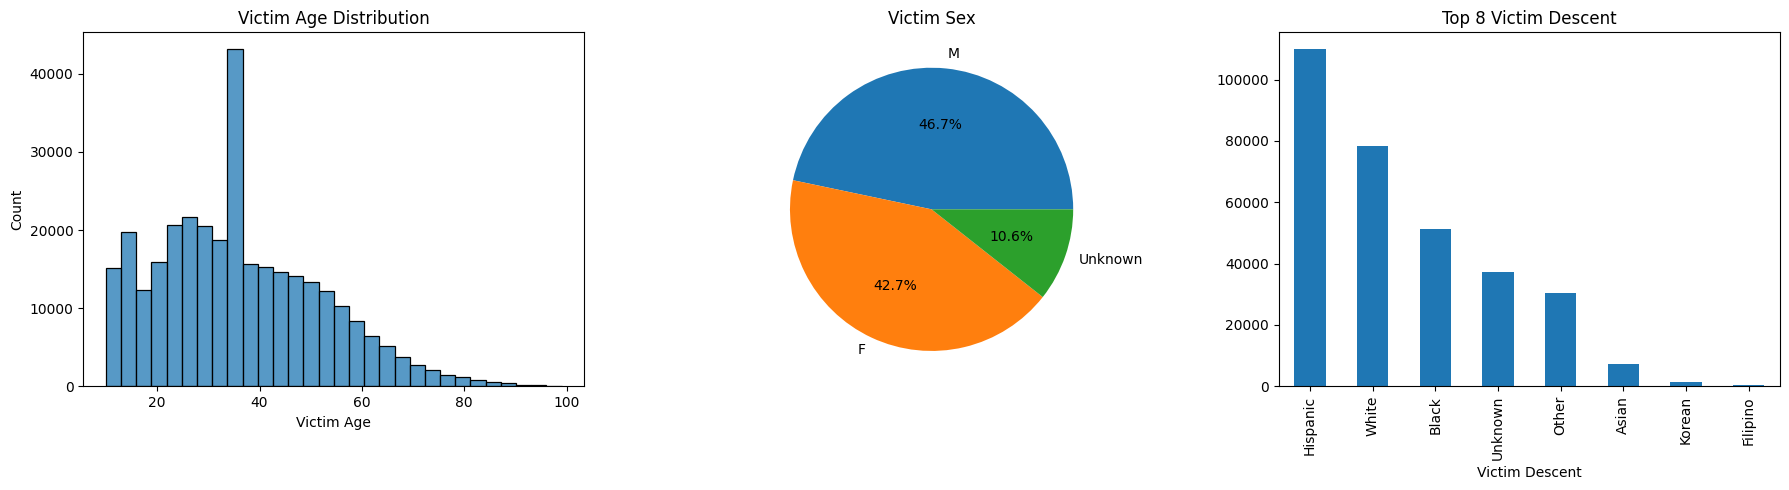

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['Victim Age'], bins=30, ax=axes[0])
axes[0].set_title('Victim Age Distribution')

df['Victim Sex'].value_counts().plot.pie(ax=axes[1], autopct='%1.1f%%', title='Victim Sex')

df['Victim Descent'].value_counts().head(8).plot.bar(ax=axes[2])
axes[2].set_title('Top 8 Victim Descent')

plt.tight_layout()
plt.show()


Geographic crime map:

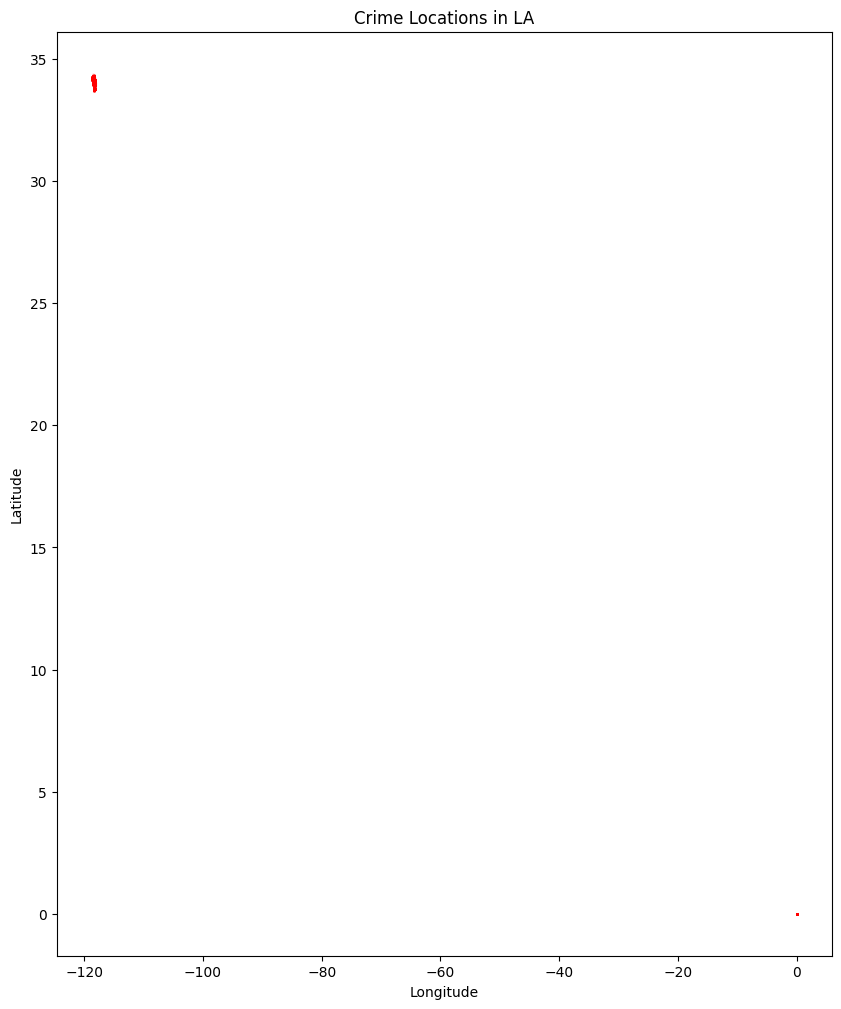

In [36]:
sample = df.sample(50000, random_state=42)
plt.figure(figsize=(10, 12))
plt.scatter(sample['Longitude'], sample['Latitude'], alpha=0.05, s=1, c='red')
plt.title('Crime Locations in LA')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


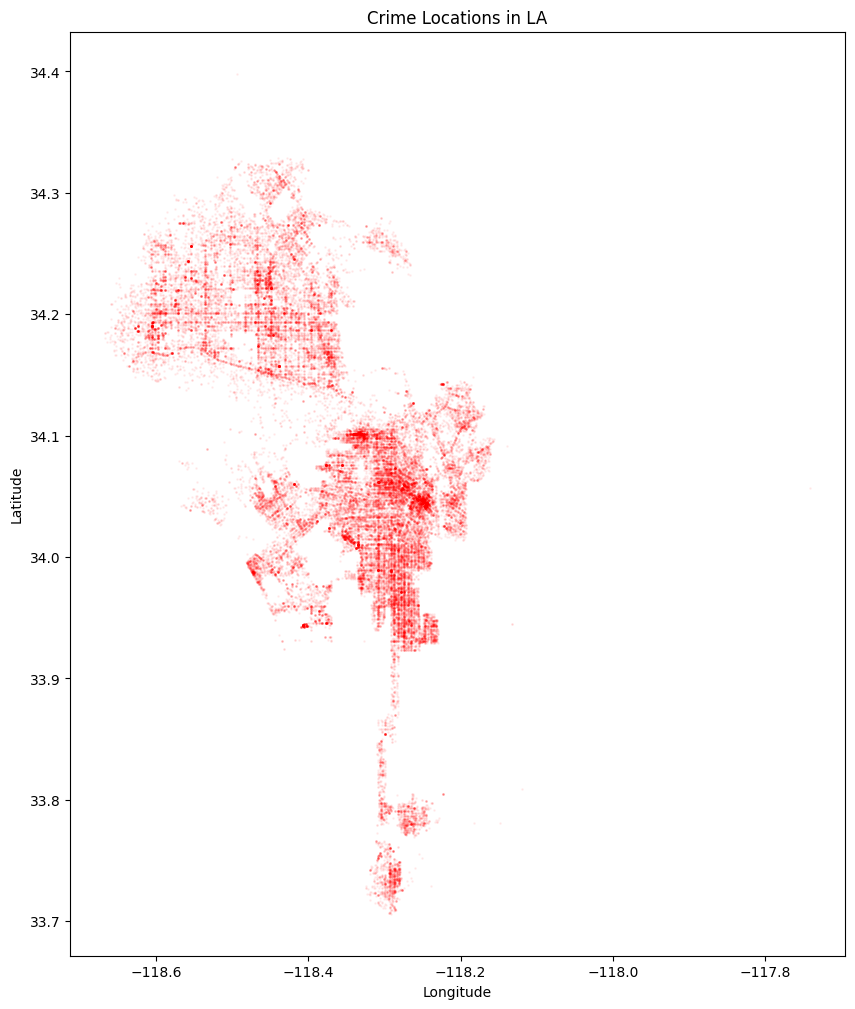

In [37]:
# removing rows where lat/lon is 0
df = df[(df['Latitude'] != 0) & (df['Longitude'] != 0)]

# now plot again
sample = df.sample(min(50000, len(df)), random_state=42)
plt.figure(figsize=(10, 12))
plt.scatter(sample['Longitude'], sample['Latitude'], alpha=0.05, s=1, c='red')
plt.title('Crime Locations in LA')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


Feature Engineering Time features

In [38]:
df['Quarter']    = df['Date Occurred'].dt.quarter
df['DayOfMonth'] = df['Date Occurred'].dt.day
df['IsWeekend']  = (df['DayOfWeek'] >= 5).astype(int)

def time_bin(hour):
    if 0 <= hour < 6:     return 'Night'
    elif 6 <= hour < 12:  return 'Morning'
    elif 12 <= hour < 18: return 'Afternoon'
    else:                 return 'Evening'

df['TimeBin'] = df['Hour Occurred'].apply(time_bin)


feature — Report Delay:

In [39]:
df['Report_Delay_Days'] = (df['Date Reported'] - df['Date Occurred']).dt.days
df['Report_Delay_Days'] = df['Report_Delay_Days'].clip(0, 365)


feature — Frequency Encoding:

In [40]:
area_freq    = df['Area ID'].value_counts()
premise_freq = df['Premise Code'].value_counts()

df['Area_Crime_Frequency']    = df['Area ID'].map(area_freq)
df['Premise_Crime_Frequency'] = df['Premise Code'].map(premise_freq)

df['MO_Code_Count'] = df['MO Codes'].str.split().apply(lambda x: len(x) if isinstance(x, list) else 0)


feature — Target Variable (Crime_Category):

In [41]:
def categorize_crime(desc):
    desc = str(desc).upper()
    if any(w in desc for w in ['THEFT','STEAL','BURGLARY','ROBBERY','SHOPLIFTING']):
        return 'Property Crime'
    elif any(w in desc for w in ['ASSAULT','BATTERY','SHOOTING','HOMICIDE','MURDER']):
        return 'Violent Crime'
    elif any(w in desc for w in ['RAPE','SEX','LEWD','INDECENT']):
        return 'Sex Crime'
    elif any(w in desc for w in ['VEHICLE','AUTO','BIKE']):
        return 'Vehicle Crime'
    elif any(w in desc for w in ['VANDAL','GRAFFITI','ARSON']):
        return 'Vandalism'
    elif any(w in desc for w in ['DRUG','NARCOTIC']):
        return 'Drug Crime'
    elif any(w in desc for w in ['FRAUD','FORGERY','COUNTERFEIT','IDENTITY']):
        return 'Financial Crime'
    else:
        return 'Other'

df['Crime_Category'] = df['Crime Code Description'].apply(categorize_crime)
print(df['Crime_Category'].value_counts())


Crime_Category
Property Crime     148544
Violent Crime       66631
Other               32417
Vandalism           30615
Vehicle Crime       26610
Sex Crime            6815
Financial Crime      4106
Drug Crime              7
Name: count, dtype: int64


feature — Label Encoding:

In [42]:
from sklearn.preprocessing import LabelEncoder

cat_cols = ['Victim Sex', 'Victim Descent', 'Area Name',
            'Premise Description', 'Weapon Description',
            'TimeBin', 'Status Description']

le = LabelEncoder()
for col in cat_cols:
    df[col + '_Enc'] = le.fit_transform(df[col].astype(str))

print('Done! New columns:', [c + '_Enc' for c in cat_cols])


Done! New columns: ['Victim Sex_Enc', 'Victim Descent_Enc', 'Area Name_Enc', 'Premise Description_Enc', 'Weapon Description_Enc', 'TimeBin_Enc', 'Status Description_Enc']


ML Model Training

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = [
    'Victim Age', 'Victim Sex_Enc', 'Victim Descent_Enc',
    'Hour Occurred', 'DayOfWeek', 'Month', 'IsWeekend', 'TimeBin_Enc',
    'Area ID', 'Area_Crime_Frequency',
    'Premise Code', 'Premise_Crime_Frequency',
    'Armed', 'Report_Delay_Days', 'MO_Code_Count',
    'Latitude', 'Longitude', 'Year', 'Quarter'
]

X = df[feature_cols]
y = df['Crime_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print('\nClass distribution:')
print(y_train.value_counts(normalize=True).mul(100).round(1))


Train: (252596, 19)  |  Test: (63149, 19)

Class distribution:
Crime_Category
Property Crime     47.0
Violent Crime      21.1
Other              10.3
Vandalism           9.7
Vehicle Crime       8.4
Sex Crime           2.2
Financial Crime     1.3
Drug Crime          0.0
Name: proportion, dtype: float64


model — Logistic Regression (Baseline):

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print('=== Logistic Regression ===')
print(classification_report(y_test, y_pred_lr))


=== Logistic Regression ===
                 precision    recall  f1-score   support

     Drug Crime       0.00      1.00      0.00         1
Financial Crime       0.05      0.65      0.09       821
          Other       0.24      0.04      0.07      6484
 Property Crime       0.77      0.12      0.21     29709
      Sex Crime       0.10      0.40      0.16      1363
      Vandalism       0.26      0.50      0.34      6123
  Vehicle Crime       0.74      0.88      0.80      5322
  Violent Crime       0.63      0.94      0.75     13326

       accuracy                           0.40     63149
      macro avg       0.35      0.57      0.31     63149
   weighted avg       0.61      0.40      0.37     63149



model — Random Forest:

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf))


=== Random Forest ===


/home/robuntu/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/robuntu/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                 precision    recall  f1-score   support

     Drug Crime       0.00      0.00      0.00         1
Financial Crime       0.10      0.63      0.18       821
          Other       0.40      0.25      0.30      6484
 Property Crime       0.82      0.57      0.67     29709
      Sex Crime       0.20      0.28      0.24      1363
      Vandalism       0.52      0.54      0.53      6123
  Vehicle Crime       0.83      0.91      0.87      5322
  Violent Crime       0.65      0.95      0.77     13326

       accuracy                           0.64     63149
      macro avg       0.44      0.52      0.44     63149
   weighted avg       0.69      0.64      0.64     63149



/home/robuntu/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


 Feature Importance

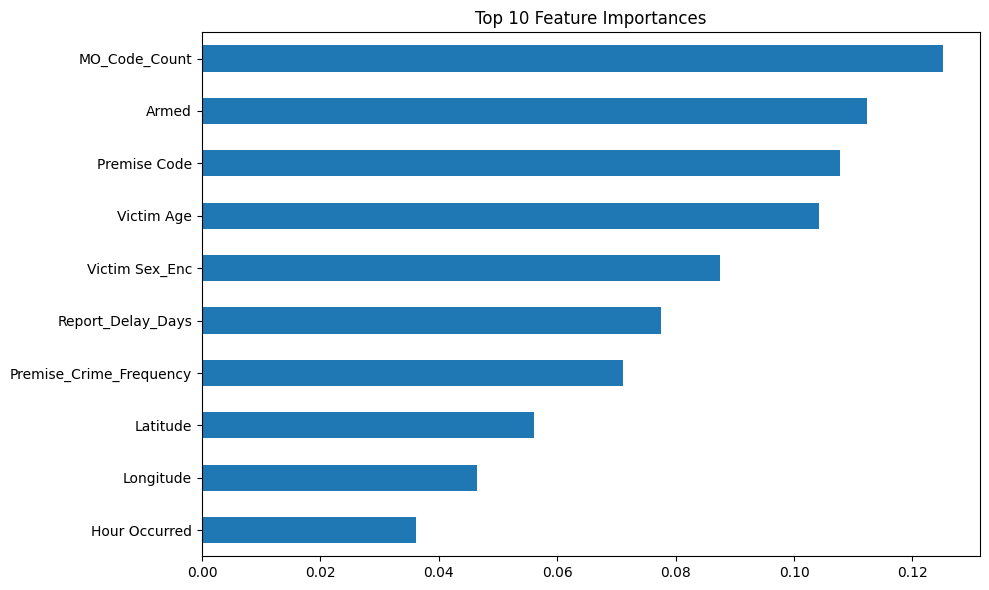

In [46]:
importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances.sort_values().tail(10).plot.barh(figsize=(10, 6))
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()


step — Confusion Matrix:

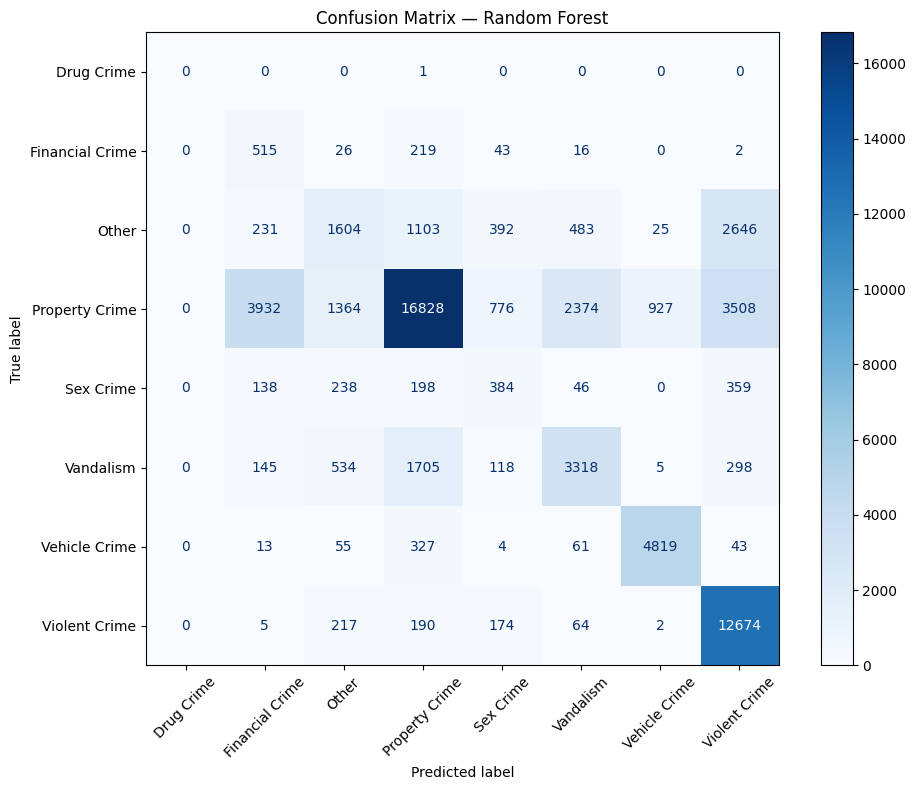

In [47]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=rf.classes_,
    xticks_rotation=45,
    cmap='Blues',
    ax=ax
)
plt.title('Confusion Matrix — Random Forest')
plt.tight_layout()
plt.show()


SMOTE algorithm / technique (data preprocessing method)

In [48]:
# installing imbalanced-learn if not installed
import subprocess
subprocess.run(['pip', 'install', 'imbalanced-learn', 'xgboost'], capture_output=True)
print('Done!')


Done!


SMOTE apply

In [49]:

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Before SMOTE:')
print(y_train.value_counts())
print('\nAfter SMOTE:')
print(pd.Series(y_train_sm).value_counts())


Before SMOTE:
Crime_Category
Property Crime     118835
Violent Crime       53305
Other               25933
Vandalism           24492
Vehicle Crime       21288
Sex Crime            5452
Financial Crime      3285
Drug Crime              6
Name: count, dtype: int64

After SMOTE:
Crime_Category
Violent Crime      118835
Property Crime     118835
Vehicle Crime      118835
Vandalism          118835
Other              118835
Sex Crime          118835
Financial Crime    118835
Drug Crime         118835
Name: count, dtype: int64


XGBoost train 

In [50]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

le_target = LabelEncoder()
y_train_enc = le_target.fit_transform(y_train_sm)
y_test_enc  = le_target.transform(y_test)

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    n_jobs=-1,
    random_state=42
)
xgb.fit(X_train_sm, y_train_enc)
y_pred_xgb = le_target.inverse_transform(xgb.predict(X_test))

print('=== XGBoost + SMOTE ===')
print(classification_report(y_test, y_pred_xgb))


=== XGBoost + SMOTE ===


/home/robuntu/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


                 precision    recall  f1-score   support

     Drug Crime       0.00      0.00      0.00         1
Financial Crime       0.16      0.33      0.21       821
          Other       0.41      0.25      0.31      6484
 Property Crime       0.79      0.73      0.76     29709
      Sex Crime       0.22      0.27      0.24      1363
      Vandalism       0.59      0.48      0.53      6123
  Vehicle Crime       0.83      0.91      0.87      5322
  Violent Crime       0.68      0.90      0.78     13326

       accuracy                           0.69     63149
      macro avg       0.46      0.48      0.46     63149
   weighted avg       0.69      0.69      0.68     63149



/home/robuntu/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/robuntu/.local/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
https://drive.google.com/drive/folders/1MHO70tPVdxu_wd-cE2GZrDJKn3LEdky-?usp=drive_link